In [5]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pyreadr
from cmdstanpy import CmdStanModel

In [25]:
df = pyreadr.read_r('OD_all_ICs.Rda')[None]
df['missing_data'] = df['OD'].isna()
df['training_data'] = True
df['testing_data'] = False
df = df.loc[df['training_data'] | df['testing_data']]
df['training_data'] = df['training_data'] & ~df['missing_data']
df['testing_data'] = df['testing_data'] & ~df['missing_data']
df

,time,temp,OD,ID,fungal_ic,technical_reps,biological_reps,blanks,missing_data,training_data,testing_data
0,0.0,30.5,0.120,1.0,0.0,R1,1.0,True,False,True,False
1,1.0,37.0,0.122,1.0,0.0,R1,1.0,True,False,True,False
2,2.0,37.0,0.124,1.0,0.0,R1,1.0,True,False,True,False
3,3.0,37.0,0.125,1.0,0.0,R1,1.0,True,False,True,False
4,4.0,37.0,0.125,1.0,0.0,R1,1.0,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
1165,21.0,37.0,0.304,45.0,200000.0,R3,3.0,False,False,True,False
1166,22.0,37.0,0.324,45.0,200000.0,R3,3.0,False,False,True,False
1167,23.0,37.0,0.346,45.0,200000.0,R3,3.0,False,False,True,False
1168,24.0,37.0,0.367,45.0,200000.0,R3,3.0,False,False,True,False


In [73]:
stan_data = {
    'N_obs': df['training_data'].sum().item(),
    'N_miss': df['missing_data'].sum().item(),
    'N_pred': df['testing_data'].sum().item(),
    'N_c': df['blanks'].sum().item(),
    'N_exp': len(df) - df['blanks'].sum().item(),
    'c_idx': [i.item() + 1 for i in np.where(df['blanks'])[0]],
    'exp_idx': [i.item() + 1 for i in np.where(~df['blanks'])[0]],
    'y_train_idx': [i.item() + 1 for i in np.where(df['training_data'])[0]],
    'y_missing_idx': [i.item() + 1 for i in np.where(df['missing_data'])[0]],
    'y_test_idx': [i.item() + 1 for i in np.where(df['testing_data'])[0]],
    'IC': df['fungal_ic'],
    'y_obs_train': df['OD'][df['training_data']],
    'y_obs_test': df['OD'][df['testing_data']],
    'time': df['time'],
    'mu_0': 1,
    'include_likelihood': True
}

In [74]:
fit = CmdStanModel(stan_file='logistic_OD_calibration.stan').sample(stan_data, chains=4)

19:06:34 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

19:06:56 - cmdstanpy - INFO - CmdStan done processing.
19:06:56 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'logistic_OD_calibration.stan', line 59, column 4 to column 22)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'logistic_OD_calibration.stan', line 59, column 4 to column 22)
	Exception: lognormal_lpdf: Scale parameter is inf, but must be positive finite! (in 'logistic_OD_calibration.stan', line 67, column 8 to column 65)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'logistic_OD_calibration.stan', line 59, column 4 to column 22)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'logistic_OD_calibration.stan', line 59, column 4 to column 22)
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'logistic_OD_calibration.stan', line 59, column 4 to column 22)
	Except

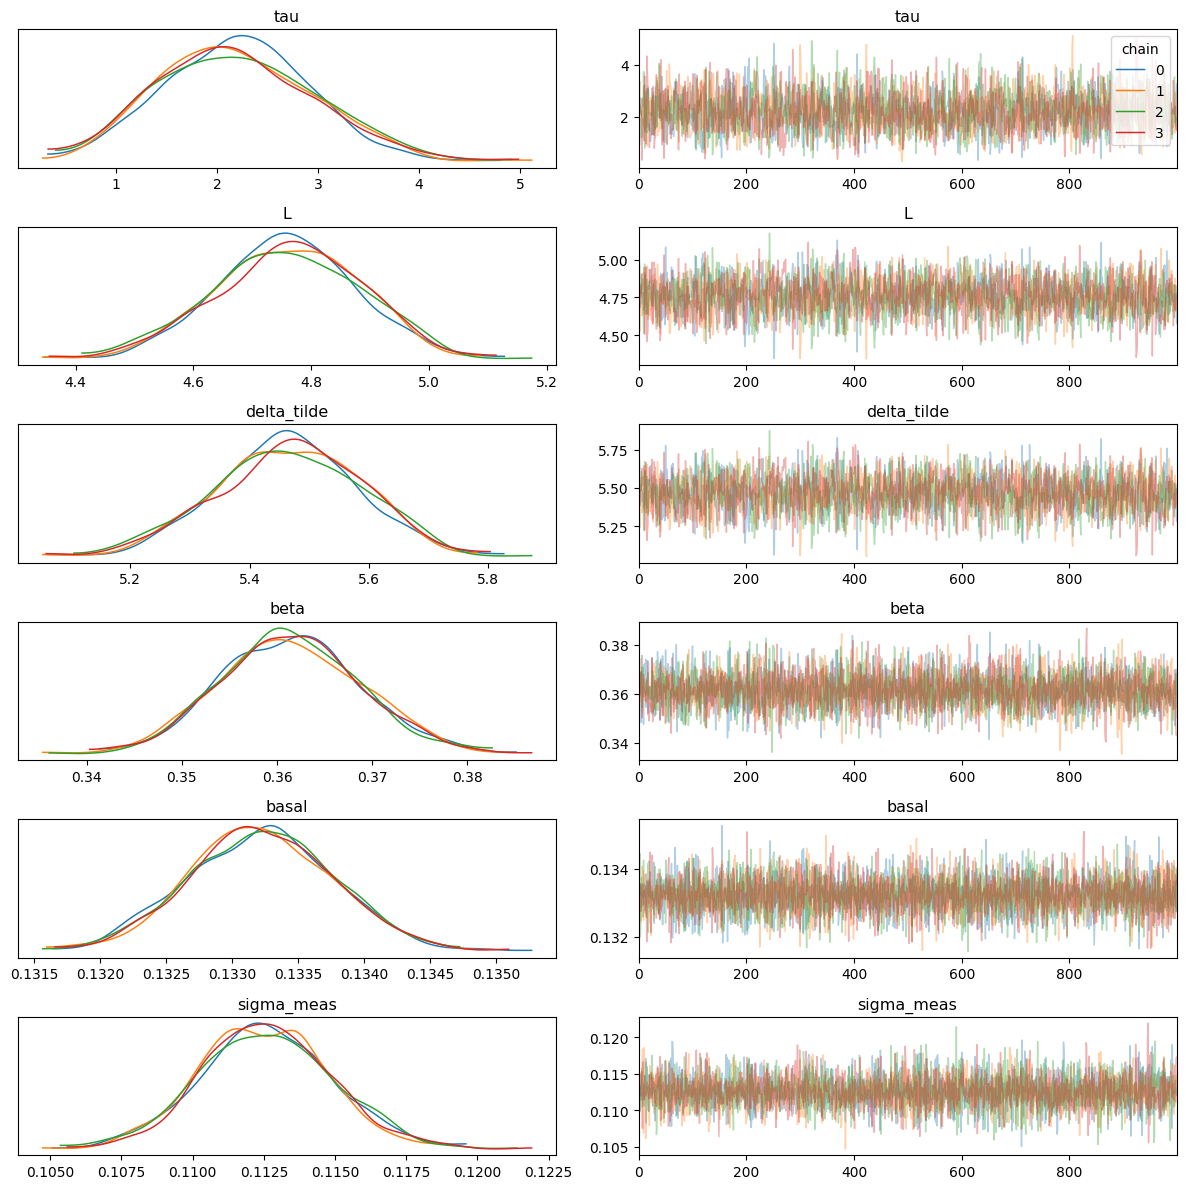

In [75]:
az.plot_trace(fit, var_names=('tau', 'L', 'delta_tilde', 'beta', 'basal', 'sigma_meas'), compact=False, legend=True)
plt.tight_layout()

In [76]:
fit.summary().head()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,3033.240000,0.077219,3.325770,3.196710,3027.450000,3033.650000,3037.95000,1866.73,2298.51,39.3659,1.00155
tau,2.189860,0.014909,0.761849,0.792867,1.003330,2.158830,3.50491,2594.71,2434.66,54.7177,1.00215
L,4.760130,0.002448,0.121761,0.123160,4.553760,4.761360,4.95711,2496.18,2732.31,52.6397,1.00084
delta_tilde,5.465330,0.002431,0.120599,0.122898,5.259960,5.467000,5.66087,2480.78,2729.94,52.3150,1.00116
beta,0.361405,0.000101,0.007318,0.007322,0.349669,0.361215,0.37389,5290.25,3209.01,111.5620,1.00177


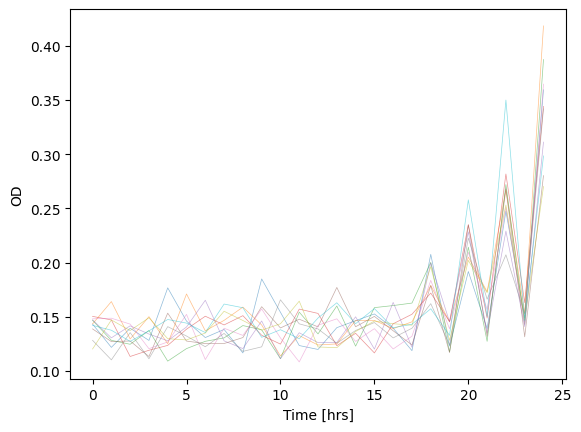

In [143]:
keys = [f'y_tot[{i}]' for i in np.arange(1, 1000, 1000//25)]
sample_draws = np.random.randint(0, 4000, 10)
f = fit.draws_pd()[keys].loc[sample_draws].T.to_numpy()
plt.plot(f, alpha=.5, linewidth=.5, zorder=2)
plt.xlabel('Time [hrs]')
plt.ylabel('OD')
plt.show()